# Grid Search Visualisation Ã¢â‚¬â€ MCTS & MCGS

Loads results from MLflow experiments `mcts-grid-thesis` and `mcgs-grid-thesis` and produces:
- Heatmaps of mean `probability_drop` over the (c, alpha) grid, one per `num_rollouts`
- Side-by-side comparison of MCTS vs MCGS
- Time and evaluation-count diagnostics

Each parent (multirun) run aggregates 30 nested per-image child runs.

In [2]:
import os

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns


MLFLOW_URI = "https://mlflow.rationai.cloud.e-infra.cz/"
EXPERIMENTS = {
    "mcts": "mcts-grid-thesis",
    "mcgs": "mcgs-grid-thesis",
}

# Set credentials before connecting (or export them in the shell).
os.environ["MLFLOW_TRACKING_USERNAME"] = "YOUR_MLFLOW_USERNAME"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "YOUR_MLFLOW_PASSWORD"

mlflow.set_tracking_uri(MLFLOW_URI)
client = mlflow.MlflowClient()
sns.set_theme(style="whitegrid")

## Load runs into a DataFrame

We pull all runs in each experiment, then aggregate child runs (per image) under each parent (per multirun config).

In [3]:
PARAM_COLS = [
    "method.num_rollouts",
    "method.num_evals",
    "method.exploration_c",
    "method.alpha",
    "desired_length",
    "sigma",
]
METRIC_COLS = [
    "region_0/probability_drop",
    "region_0/final_score",
    "region_0/evaluations_count",
    "region_0/original_prob",
    "region_0/masked_prob",
    "original_log_odds",
    "time_seconds",
]


def load_experiment(algo: str, exp_name: str) -> pd.DataFrame:
    exp = client.get_experiment_by_name(exp_name)
    if exp is None:
        print(f"[warn] experiment not found: {exp_name}")
        return pd.DataFrame()
    runs = mlflow.search_runs(
        experiment_ids=[exp.experiment_id],
        max_results=10000,
        output_format="pandas",
    )
    if runs.empty:
        return runs
    runs["algorithm"] = algo
    return runs


all_runs = pd.concat(
    [load_experiment(a, n) for a, n in EXPERIMENTS.items()], ignore_index=True
)
print(f"Loaded {len(all_runs)} runs total")
all_runs.head()

Loaded 2790 runs total


,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.region_0/original_prob,metrics.region_0/trajectory_best_score,metrics.region_0/evaluations_count,metrics.time_seconds,...,params.logger.experiment_name,params.model.weights,params.data.limit,tags.mlflow.parentRunId,tags.mlflow.runName,tags.mlflow.source.name,tags.mlflow.source.git.commit,tags.mlflow.user,tags.mlflow.source.type,algorithm
0,e7c03909663a44419e03c6512e36beb6,77,FINISHED,mlflow-artifacts:/77/e7c03909663a44419e03c6512...,2026-04-29 16:31:07.432000+00:00,2026-04-29 16:31:38.256000+00:00,0.999939,2.246022,99962.0,27.396211,...,None,None,None,2354c54d4b214299813921ce87467ba8,imagenets_0026.jpg,REPO_ROOT/ciao/__main__.py,e33772f6eabfdc31663687d8a71788965f60a185,YOUR_MLFLOW_USERNAME,LOCAL,mcts
1,41f02ce4da464cfa9d79aa205ddeafb3,77,FINISHED,mlflow-artifacts:/77/41f02ce4da464cfa9d79aa205...,2026-04-29 16:30:33.534000+00:00,2026-04-29 16:31:07.148000+00:00,0.698333,6.214314,99968.0,29.747028,...,None,None,None,2354c54d4b214299813921ce87467ba8,imagenets_0025.jpg,REPO_ROOT/ciao/__main__.py,e33772f6eabfdc31663687d8a71788965f60a185,YOUR_MLFLOW_USERNAME,LOCAL,mcts
2,e445eda7d7a94bdd9c9dbdaa31f1e453,77,FINISHED,mlflow-artifacts:/77/e445eda7d7a94bdd9c9dbdaa3...,2026-04-29 16:29:59.382000+00:00,2026-04-29 16:30:33.239000+00:00,0.984082,2.405319,99968.0,29.947900,...,None,None,None,2354c54d4b214299813921ce87467ba8,imagenets_0017.jpg,REPO_ROOT/ciao/__main__.py,e33772f6eabfdc31663687d8a71788965f60a185,YOUR_MLFLOW_USERNAME,LOCAL,mcts
3,0b3a2c64145c4c548c4bf08394130a13,77,FINISHED,mlflow-artifacts:/77/0b3a2c64145c4c548c4bf0839...,2026-04-29 16:29:25.886000+00:00,2026-04-29 16:29:59.094000+00:00,0.885436,3.915620,99968.0,29.747654,...,None,None,None,2354c54d4b214299813921ce87467ba8,imagenets_0029.jpg,REPO_ROOT/ciao/__main__.py,e33772f6eabfdc31663687d8a71788965f60a185,YOUR_MLFLOW_USERNAME,LOCAL,mcts
4,dbcebdbd02504d8690dc0d0f368b2e3b,77,FINISHED,mlflow-artifacts:/77/dbcebdbd02504d8690dc0d0f3...,2026-04-29 16:28:52.424000+00:00,2026-04-29 16:29:25.590000+00:00,0.999721,6.435531,99968.0,29.776831,...,None,None,None,2354c54d4b214299813921ce87467ba8,imagenets_0004.jpg,REPO_ROOT/ciao/__main__.py,e33772f6eabfdc31663687d8a71788965f60a185,YOUR_MLFLOW_USERNAME,LOCAL,mcts


In [4]:
PARENT_TAG = "tags.mlflow.parentRunId"

child_runs = all_runs[all_runs[PARENT_TAG].notna()].copy()
parent_runs = all_runs[all_runs[PARENT_TAG].isna()].copy()
print(f"Parent runs: {len(parent_runs)}, child (per-image) runs: {len(child_runs)}")

# Show actual param column names logged by the parent runs.
parent_param_cols = sorted(c for c in parent_runs.columns if c.startswith("params."))
print("Params found in parent runs:")
print(parent_param_cols)

# Children have those param column NAMES but NaN values (params are only logged on parent).
# Drop them from children so the join below brings in the real values from the parent row.
overlap = [c for c in parent_param_cols if c in child_runs.columns]
child_runs = child_runs.drop(columns=overlap)

# Merge ALL params from parent into child via parentRunId.
parent_params = parent_runs.set_index("run_id")[parent_param_cols]
child_runs = child_runs.join(parent_params, on=PARENT_TAG)

# Coerce numeric.
for col in parent_param_cols:
    if col in child_runs.columns:
        child_runs[col] = pd.to_numeric(child_runs[col], errors="coerce")
metric_full_cols = [f"metrics.{m}" for m in METRIC_COLS]
for col in metric_full_cols:
    if col in child_runs.columns:
        child_runs[col] = pd.to_numeric(child_runs[col], errors="coerce")

# Rename to short names; adjust keys here if _flatten_params uses different separators.
rename_map = {
    "params.method.num_rollouts": "num_rollouts",
    "params.method.num_evals": "num_evals",
    "params.method.exploration_c": "c",
    "params.method.alpha": "alpha",
    "metrics.region_0/probability_drop": "prob_drop",
    "metrics.region_0/final_score": "final_score",
    "metrics.region_0/evaluations_count": "evals_used",
    "metrics.region_0/original_prob": "original_prob",
    "metrics.region_0/masked_prob": "masked_prob",
    "metrics.time_seconds": "time_s",
    "tags.mlflow.runName": "image_name",
}
rename_map = {k: v for k, v in rename_map.items() if k in child_runs.columns}
child_runs = child_runs.rename(columns=rename_map)

# Relative drop = fraction of original probability removed by masking the explanation.
child_runs["rel_drop"] = child_runs["prob_drop"] / child_runs["original_prob"]

child_runs[
    [
        "algorithm",
        "image_name",
        "num_rollouts",
        "c",
        "alpha",
        "original_prob",
        "prob_drop",
        "rel_drop",
        "time_s",
    ]
].head()

Parent runs: 90, child (per-image) runs: 2700
Params found in parent runs:
['params.batch_size', 'params.class_name', 'params.classes._target_', 'params.data.batch_path', 'params.data.limit', 'params.data.name', 'params.desired_length', 'params.logger.experiment_name', 'params.logger.log_figures', 'params.logger.run_name', 'params.logger.tracking_uri', 'params.max_regions', 'params.method._target_', 'params.method.alpha', 'params.method.exploration_c', 'params.method.num_evals', 'params.method.num_rollouts', 'params.model._target_', 'params.model.weights', 'params.region_0/masked_top_class_idx', 'params.region_0/masked_top_class_name', 'params.replacement._partial_', 'params.replacement._target_', 'params.seed', 'params.segmentation._target_', 'params.segmentation.hex_radius', 'params.sigma', 'params.target_class_idx']


,algorithm,image_name,num_rollouts,c,alpha,original_prob,prob_drop,rel_drop,time_s
0,mcts,imagenets_0026.jpg,64,5.0,1.0,0.999939,0.000514,0.000514,27.396211
1,mcts,imagenets_0025.jpg,64,5.0,1.0,0.698333,0.693723,0.993399,29.747028
2,mcts,imagenets_0017.jpg,64,5.0,1.0,0.984082,0.136496,0.138704,29.947900
3,mcts,imagenets_0029.jpg,64,5.0,1.0,0.885436,0.751650,0.848904,29.747654
4,mcts,imagenets_0004.jpg,64,5.0,1.0,0.999721,0.147971,0.148013,29.776831


## Aggregate per (algorithm, num_rollouts, c, alpha)

Mean and std across the 30 images.

In [5]:
GROUP_KEYS = ["algorithm", "num_rollouts", "c", "alpha"]
VALUE_COLS = [
    "prob_drop",
    "rel_drop",
    "final_score",
    "evals_used",
    "time_s",
    "original_prob",
]

agg = (
    child_runs.groupby(GROUP_KEYS, dropna=False)[VALUE_COLS]
    .agg(["mean", "std", "count"])
    .reset_index()
)
agg.columns = [
    "_".join(c).rstrip("_") if isinstance(c, tuple) else c for c in agg.columns
]
agg = agg.sort_values(GROUP_KEYS).reset_index(drop=True)
agg.head(15)

,algorithm,num_rollouts,c,alpha,prob_drop_mean,prob_drop_std,prob_drop_count,rel_drop_mean,rel_drop_std,rel_drop_count,...,final_score_count,evals_used_mean,evals_used_std,evals_used_count,time_s_mean,time_s_std,time_s_count,original_prob_mean,original_prob_std,original_prob_count
0,mcgs,1,0.1,0.0,0.570860,0.313920,30,0.717315,0.363361,30,...,30,3087.266667,609.589117,30,15.784374,2.086786,30,0.845736,0.206046,30
1,mcgs,1,0.1,0.5,0.515431,0.300169,30,0.656950,0.364856,30,...,30,1051.600000,139.452773,30,9.626850,0.815462,30,0.845736,0.206046,30
2,mcgs,1,0.1,1.0,0.477940,0.300626,30,0.617773,0.376081,30,...,30,757.733333,98.126918,30,8.895142,0.804653,30,0.845736,0.206046,30
3,mcgs,1,0.7,0.0,0.542332,0.327804,30,0.686321,0.382903,30,...,30,9852.466667,566.668530,30,33.917615,1.861920,30,0.845736,0.206046,30
4,mcgs,1,0.7,0.5,0.582315,0.307233,30,0.728786,0.353044,30,...,30,7378.000000,1975.001493,30,28.137136,5.821188,30,0.845736,0.206046,30
5,mcgs,1,0.7,1.0,0.557151,0.314528,30,0.703205,0.368593,30,...,30,6291.966667,1653.497098,30,25.332075,4.972784,30,0.845736,0.206046,30
6,mcgs,1,1.4,0.0,0.529753,0.323374,30,0.674330,0.384850,30,...,30,10000.000000,0.000000,30,33.645561,0.264068,30,0.845736,0.206046,30
7,mcgs,1,1.4,0.5,0.555513,0.320494,30,0.700050,0.372075,30,...,30,9993.766667,34.141373,30,34.477589,0.535814,30,0.845736,0.206046,30
8,mcgs,1,1.4,1.0,0.540152,0.317505,30,0.684374,0.374717,30,...,30,9905.533333,286.793899,30,34.572109,0.799239,30,0.845736,0.206046,30
9,mcgs,1,3.0,0.0,0.519665,0.327469,30,0.661029,0.387148,30,...,30,10000.000000,0.000000,30,33.384729,0.326822,30,0.845736,0.206046,30


## Heatmap grid: mean probability drop

Rows: algorithms Ãƒâ€” `num_rollouts`. Cells: (c, alpha).

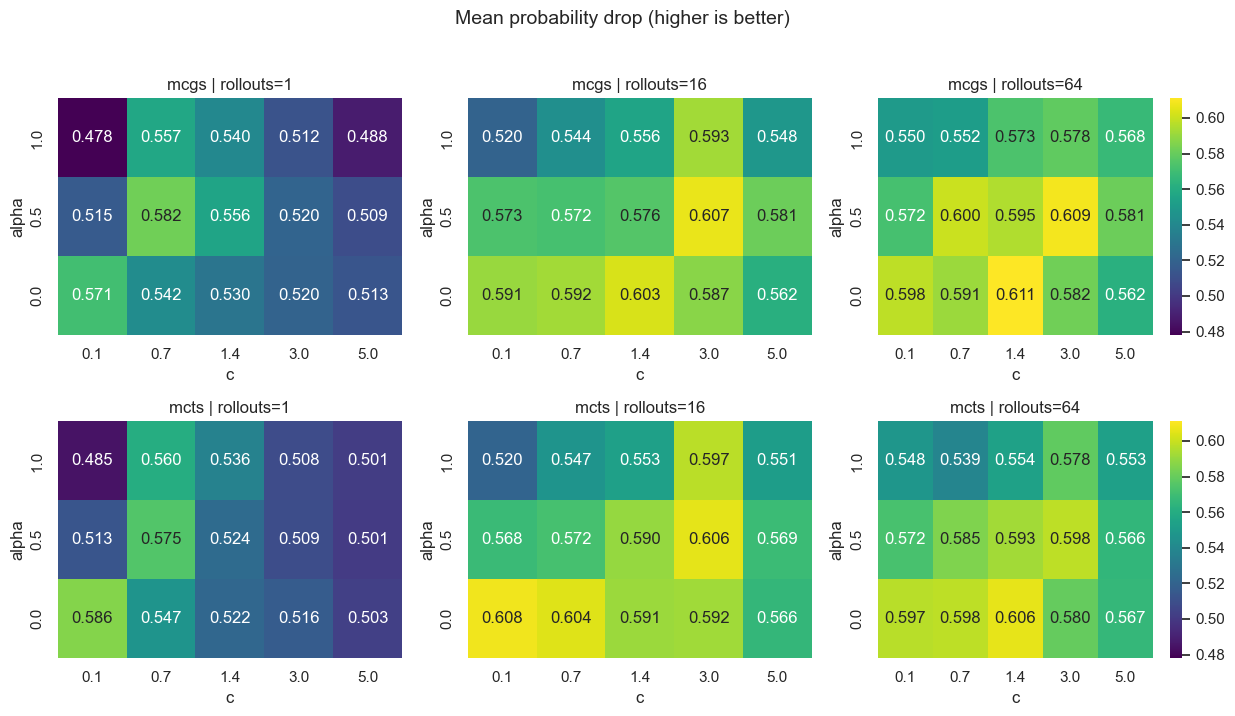

In [6]:
def plot_heatmap_grid(df: pd.DataFrame, value: str, title: str) -> None:
    algos = sorted(df["algorithm"].dropna().unique())
    rollouts = sorted(df["num_rollouts"].dropna().unique())
    fig, axes = plt.subplots(
        len(algos),
        len(rollouts),
        figsize=(4.2 * len(rollouts), 3.5 * len(algos)),
        squeeze=False,
    )
    vmin, vmax = df[value].min(), df[value].max()
    for i, algo in enumerate(algos):
        for j, rl in enumerate(rollouts):
            ax = axes[i][j]
            sub = df[(df["algorithm"] == algo) & (df["num_rollouts"] == rl)]
            if sub.empty:
                ax.set_axis_off()
                continue
            pivot = sub.pivot_table(
                index="alpha", columns="c", values=value, aggfunc="mean"
            )
            sns.heatmap(
                pivot,
                ax=ax,
                annot=True,
                fmt=".3f",
                cmap="viridis",
                vmin=vmin,
                vmax=vmax,
                cbar=(j == len(rollouts) - 1),
            )
            ax.set_title(f"{algo} | rollouts={int(rl)}")
            ax.invert_yaxis()
    fig.suptitle(title, fontsize=14, y=1.02)
    fig.tight_layout()
    plt.show()


plot_heatmap_grid(agg, "prob_drop_mean", "Mean probability drop (higher is better)")

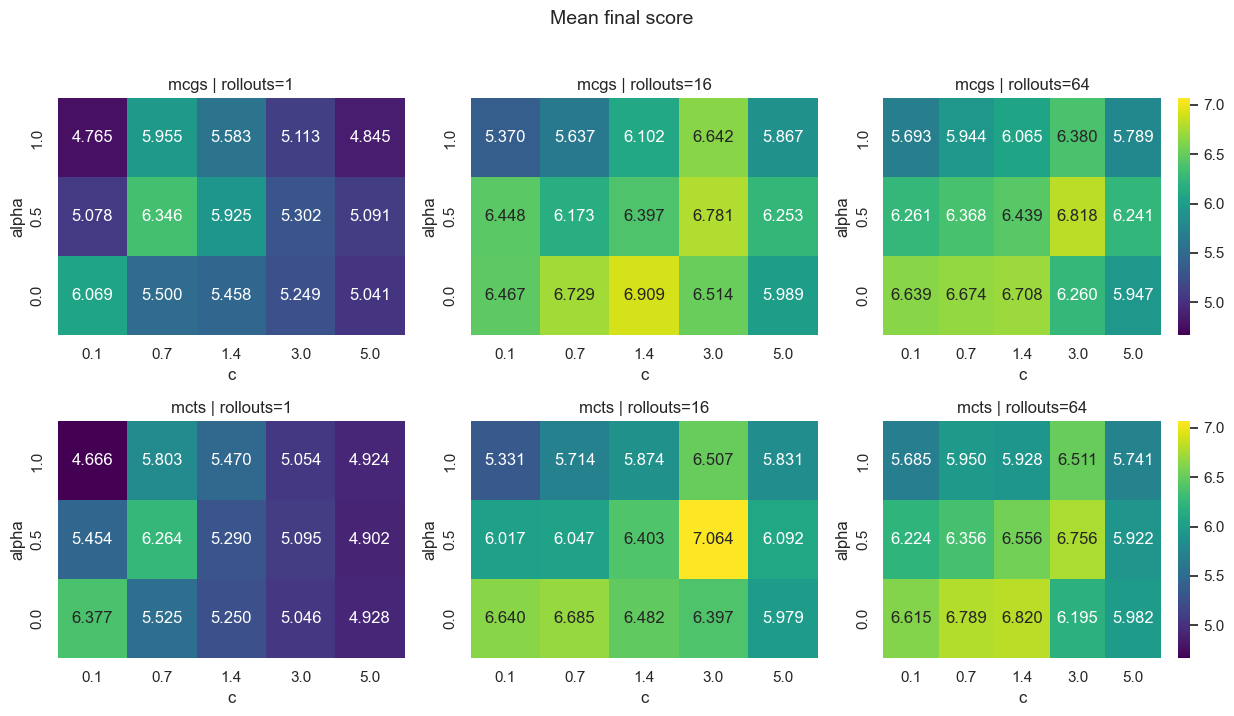

In [7]:
plot_heatmap_grid(agg, "final_score_mean", "Mean final score")

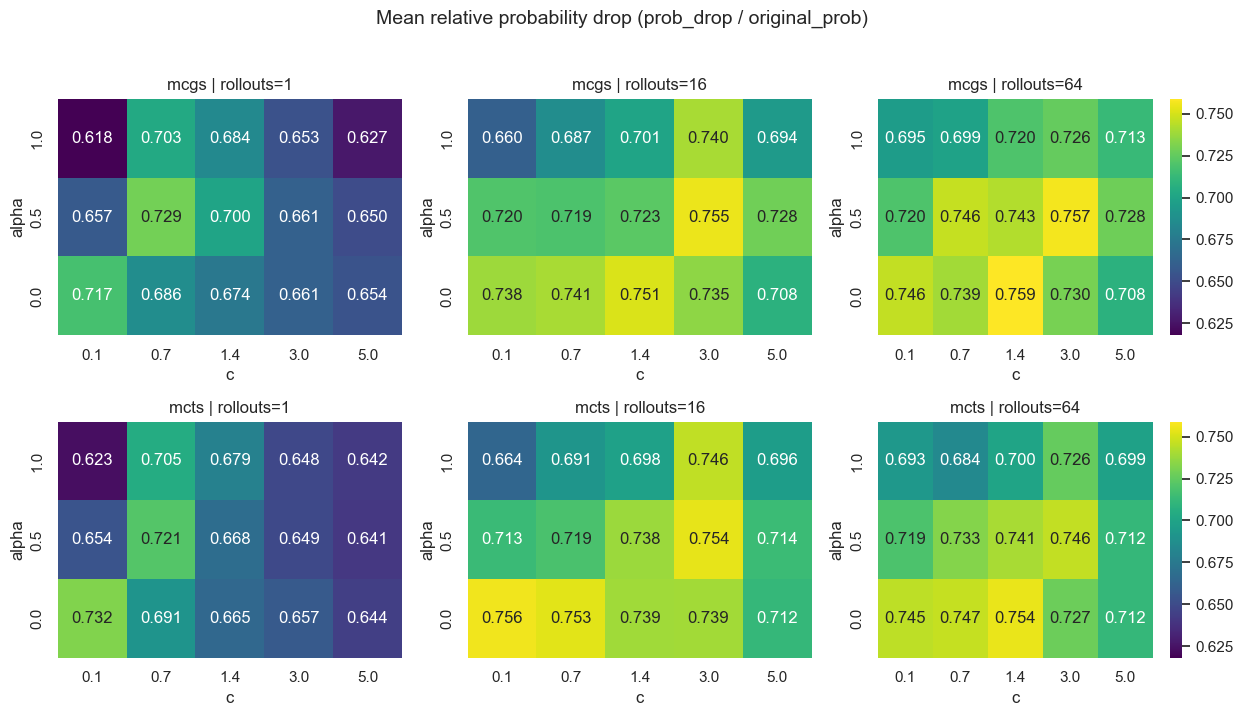

In [8]:
plot_heatmap_grid(
    agg, "rel_drop_mean", "Mean relative probability drop (prob_drop / original_prob)"
)

## MCTS vs MCGS Ã¢â‚¬â€ direct comparison

For each (c, alpha, rollouts), compute MCGS - MCTS difference in mean probability drop. Positive Ã¢â€ â€™ MCGS better.

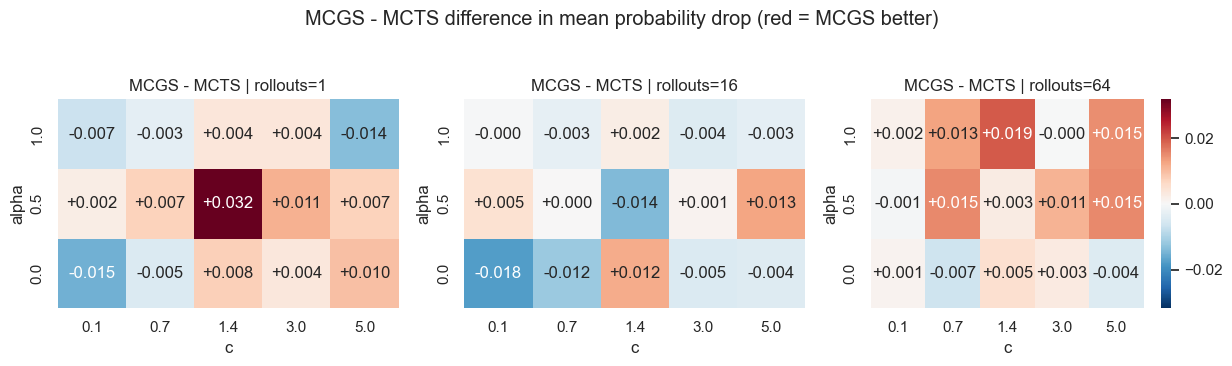

In [9]:
wide = agg.pivot_table(
    index=["num_rollouts", "c", "alpha"],
    columns="algorithm",
    values="prob_drop_mean",
).reset_index()
if "mcgs" in wide.columns and "mcts" in wide.columns:
    wide["mcgs_minus_mcts"] = wide["mcgs"] - wide["mcts"]

    rollouts = sorted(wide["num_rollouts"].dropna().unique())
    fig, axes = plt.subplots(
        1, len(rollouts), figsize=(4.2 * len(rollouts), 3.5), squeeze=False
    )
    vabs = wide["mcgs_minus_mcts"].abs().max()
    for j, rl in enumerate(rollouts):
        ax = axes[0][j]
        sub = wide[wide["num_rollouts"] == rl]
        pivot = sub.pivot_table(
            index="alpha", columns="c", values="mcgs_minus_mcts", aggfunc="mean"
        )
        sns.heatmap(
            pivot,
            ax=ax,
            annot=True,
            fmt="+.3f",
            cmap="RdBu_r",
            center=0,
            vmin=-vabs,
            vmax=vabs,
            cbar=(j == len(rollouts) - 1),
        )
        ax.set_title(f"MCGS - MCTS | rollouts={int(rl)}")
        ax.invert_yaxis()
    fig.suptitle(
        "MCGS - MCTS difference in mean probability drop (red = MCGS better)", y=1.04
    )
    fig.tight_layout()
    plt.show()
else:
    print("Need both algorithms loaded for comparison.")

## Best configurations per algorithm

In [10]:
TOP_K = 10
for algo in sorted(agg["algorithm"].dropna().unique()):
    sub = agg[agg["algorithm"] == algo].sort_values("prob_drop_mean", ascending=False)
    print(f"\nTop {TOP_K} configs by mean probability_drop Ã¢â‚¬â€ {algo}")
    print(
        sub[
            [
                "num_rollouts",
                "c",
                "alpha",
                "prob_drop_mean",
                "prob_drop_std",
                "evals_used_mean",
                "time_s_mean",
            ]
        ]
        .head(TOP_K)
        .to_string(index=False)
    )


Top 10 configs by mean probability_drop Ã¢â‚¬â€ mcgs
 num_rollouts   c  alpha  prob_drop_mean  prob_drop_std  evals_used_mean  time_s_mean
           64 1.4    0.0        0.610982       0.304615     88983.833333    25.103229
           64 3.0    0.5        0.608885       0.306382     85607.766667    23.808793
           16 3.0    0.5        0.606672       0.312388     70790.800000    26.381419
           16 1.4    0.0        0.602799       0.307437     42262.200000    17.805353
           64 0.7    0.5        0.600223       0.313962     48727.633333    14.424469
           64 0.1    0.0        0.597854       0.303794     65467.033333    18.999269
           64 1.4    0.5        0.595106       0.310697     52138.066667    15.258369
           16 3.0    1.0        0.592635       0.315381     78764.333333    28.837570
           16 0.7    0.0        0.592379       0.310951     27970.433333    13.137095
           64 0.7    0.0        0.591202       0.309548     75597.600000    21.620424

## Time-fairness sanity check

Confirm wall time per image is roughly constant across rollout sizes (the calibration's promise).

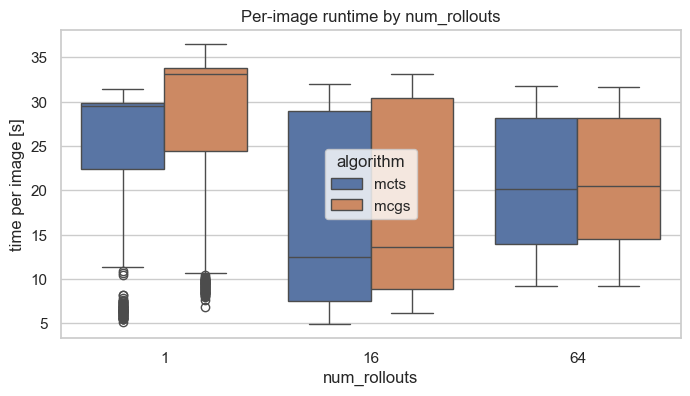

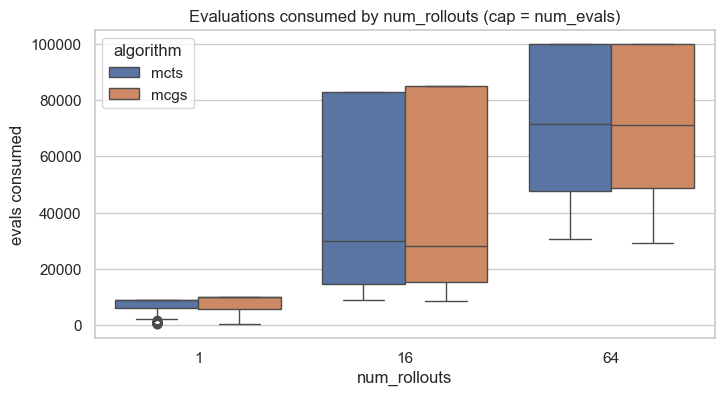

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(
    data=child_runs.dropna(subset=["num_rollouts", "time_s"]),
    x="num_rollouts",
    y="time_s",
    hue="algorithm",
    ax=ax,
)
ax.set_ylabel("time per image [s]")
ax.set_title("Per-image runtime by num_rollouts")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(
    data=child_runs.dropna(subset=["num_rollouts", "evals_used"]),
    x="num_rollouts",
    y="evals_used",
    hue="algorithm",
    ax=ax,
)
ax.set_ylabel("evals consumed")
ax.set_title("Evaluations consumed by num_rollouts (cap = num_evals)")
plt.show()

## Effect of num_rollouts at the best (c, alpha) per algorithm

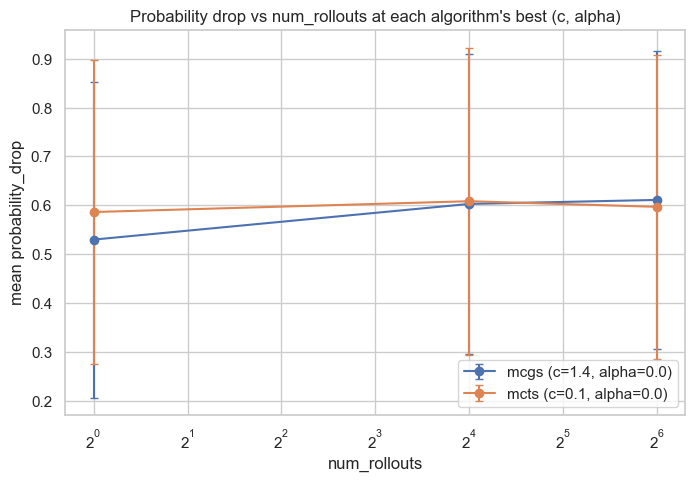

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
for algo in sorted(agg["algorithm"].dropna().unique()):
    sub = agg[agg["algorithm"] == algo]
    best_row = sub.loc[sub["prob_drop_mean"].idxmax()]
    best_c, best_a = best_row["c"], best_row["alpha"]
    line = sub[(sub["c"] == best_c) & (sub["alpha"] == best_a)].sort_values(
        "num_rollouts"
    )
    ax.errorbar(
        line["num_rollouts"],
        line["prob_drop_mean"],
        yerr=line["prob_drop_std"],
        marker="o",
        capsize=3,
        label=f"{algo} (c={best_c}, alpha={best_a})",
    )
ax.set_xscale("log", base=2)
ax.set_xlabel("num_rollouts")
ax.set_ylabel("mean probability_drop")
ax.set_title("Probability drop vs num_rollouts at each algorithm's best (c, alpha)")
ax.legend()
plt.show()

## Export the aggregated table

## Per-image summary

For each image: original probability (constant across configs Ã¢â‚¬â€ same image, same model) and the mean drop achieved across all configurations. Sorted by original probability so easy images sit on the right.

In [16]:
per_image = (
    child_runs.groupby(["algorithm", "image_name"], dropna=False)
    .agg(
        original_prob=("original_prob", "first"),
        prob_drop_mean=("prob_drop", "mean"),
        prob_drop_std=("prob_drop", "std"),
        rel_drop_mean=("rel_drop", "mean"),
        rel_drop_std=("rel_drop", "std"),
        n_configs=("prob_drop", "count"),
    )
    .reset_index()
)

# Sort images by original_prob (using mcgs values if available, else mcts).
order_algo = (
    "mcgs"
    if "mcgs" in per_image["algorithm"].unique()
    else per_image["algorithm"].iloc[0]
)
order = (
    per_image[per_image["algorithm"] == order_algo]
    .sort_values("original_prob")["image_name"]
    .tolist()
)
per_image["image_name"] = pd.Categorical(
    per_image["image_name"], categories=order, ordered=True
)
per_image = per_image.sort_values(["algorithm", "image_name"]).reset_index(drop=True)

per_image.head(10)

,algorithm,image_name,original_prob,prob_drop_mean,prob_drop_std,rel_drop_mean,rel_drop_std,n_configs
0,mcgs,imagenets_0008.jpg,0.393258,0.382650,0.008189,0.973024,0.020825,45
1,mcgs,imagenets_0007.jpg,0.431292,0.366732,0.025986,0.850310,0.060251,45
2,mcgs,imagenets_0028.jpg,0.443241,0.443091,0.000054,0.999662,0.000122,45
3,mcgs,imagenets_0012.jpg,0.498268,0.495412,0.002010,0.994268,0.004034,45
4,mcgs,imagenets_0024.jpg,0.550823,0.548147,0.003828,0.995143,0.006950,45
5,mcgs,imagenets_0023.jpg,0.594707,0.592447,0.001640,0.996199,0.002757,45
6,mcgs,imagenets_0003.jpg,0.622759,0.581937,0.014895,0.934450,0.023917,45
7,mcgs,imagenets_0025.jpg,0.698333,0.692240,0.005239,0.991274,0.007501,45
8,mcgs,imagenets_0019.jpg,0.776202,0.773093,0.002278,0.995995,0.002934,45
9,mcgs,imagenets_0029.jpg,0.885436,0.748318,0.042141,0.845140,0.047593,45


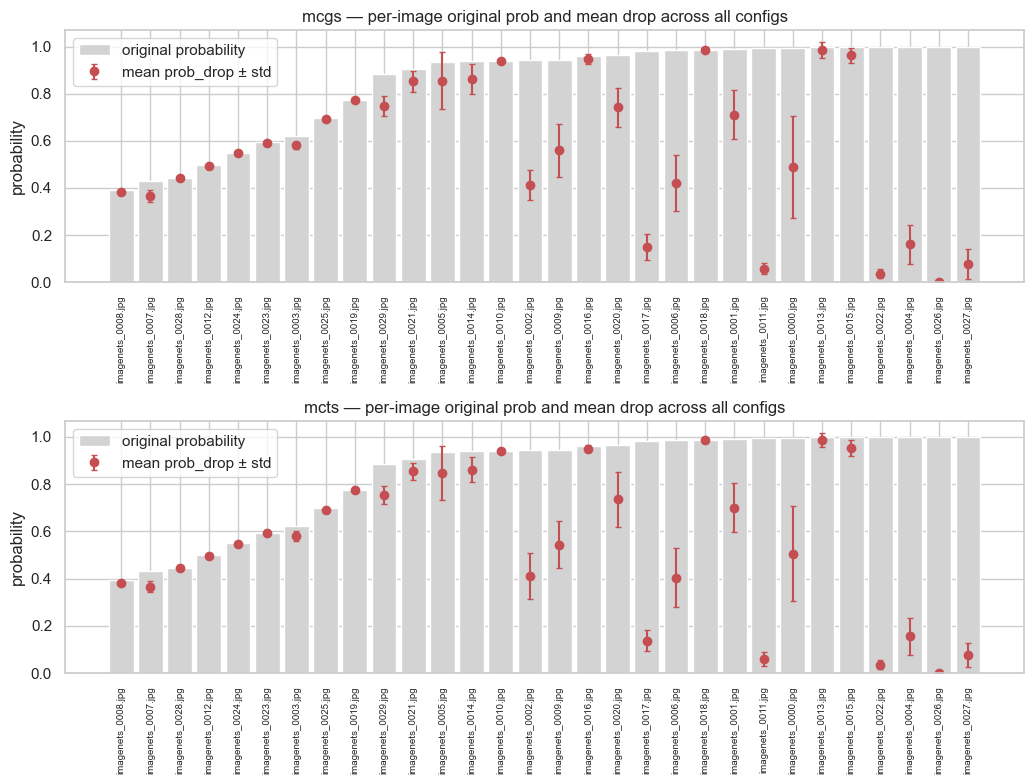

In [17]:
algos = sorted(per_image["algorithm"].dropna().unique())
fig, axes = plt.subplots(
    len(algos), 1, figsize=(max(10, 0.35 * len(order)), 4 * len(algos)), squeeze=False
)
for i, algo in enumerate(algos):
    ax = axes[i][0]
    sub = per_image[per_image["algorithm"] == algo]
    x = np.arange(len(sub))
    ax.bar(
        x,
        sub["original_prob"],
        color="lightgray",
        label="original probability",
        width=0.85,
    )
    ax.errorbar(
        x,
        sub["prob_drop_mean"],
        yerr=sub["prob_drop_std"],
        fmt="o",
        color="C3",
        ecolor="C3",
        capsize=2,
        label="mean prob_drop Ã‚Â± std",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(sub["image_name"], rotation=90, fontsize=7)
    ax.set_ylabel("probability")
    ax.set_title(
        f"{algo} Ã¢â‚¬â€ per-image original prob and mean drop across all configs"
    )
    ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

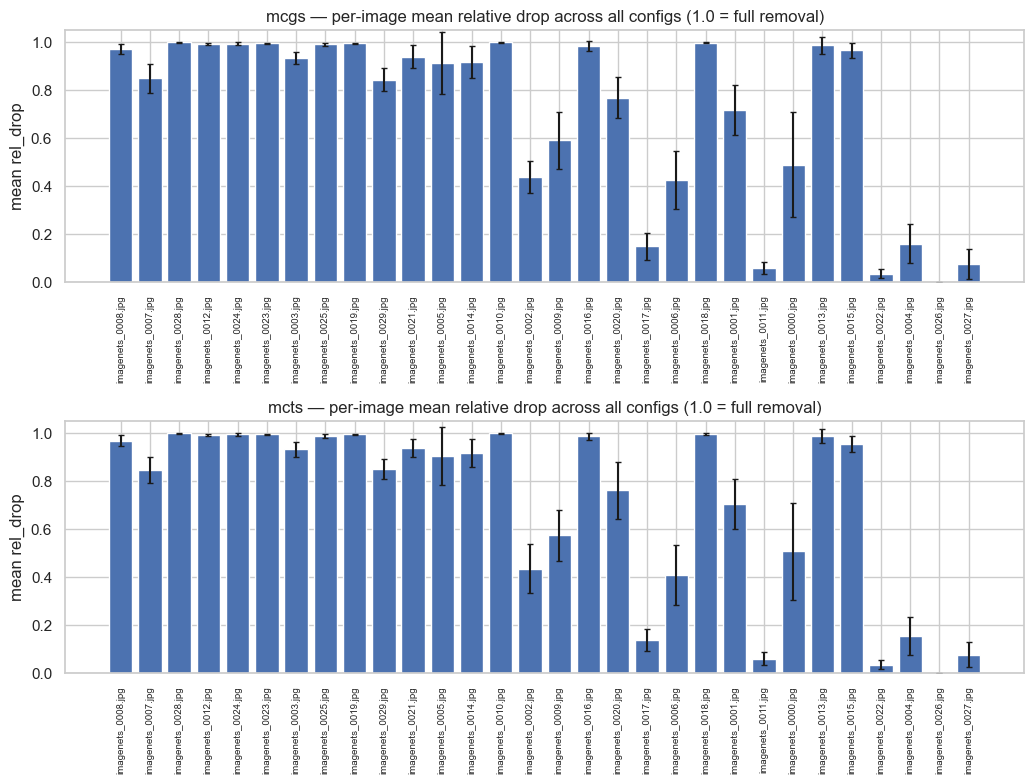

In [18]:
fig, axes = plt.subplots(
    len(algos), 1, figsize=(max(10, 0.35 * len(order)), 4 * len(algos)), squeeze=False
)
for i, algo in enumerate(algos):
    ax = axes[i][0]
    sub = per_image[per_image["algorithm"] == algo]
    x = np.arange(len(sub))
    ax.bar(x, sub["rel_drop_mean"], yerr=sub["rel_drop_std"], color="C0", capsize=2)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["image_name"], rotation=90, fontsize=7)
    ax.set_ylabel("mean rel_drop")
    ax.set_ylim(0, 1.05)
    ax.set_title(
        f"{algo} Ã¢â‚¬â€ per-image mean relative drop across all configs (1.0 = full removal)"
    )
fig.tight_layout()
plt.show()

## Stubborn-image filter

Drop images where the *best* config (across all algorithms Ãƒâ€” hyperparameters) achieves only a small relative drop. These images don't differentiate hyperparameters Ã¢â‚¬â€ the model just doesn't rely on localizable features for them, so they add noise to any aggregate.

In [19]:
STUBBORN_THRESHOLD = 0.20  # Drop image if best config achieves rel_drop below this.

best_per_image = (
    child_runs.groupby("image_name")["rel_drop"]
    .max()
    .rename("best_rel_drop")
    .reset_index()
)
stubborn = best_per_image[best_per_image["best_rel_drop"] < STUBBORN_THRESHOLD]
keep_images = set(
    best_per_image[best_per_image["best_rel_drop"] >= STUBBORN_THRESHOLD]["image_name"]
)

print(
    f"Stubborn images dropped ({len(stubborn)}): {sorted(stubborn['image_name'].tolist())}"
)
print(f"Images kept: {len(keep_images)} of {len(best_per_image)}")

child_runs_filt = child_runs[child_runs["image_name"].isin(keep_images)].copy()

Stubborn images dropped (3): ['imagenets_0011.jpg', 'imagenets_0022.jpg', 'imagenets_0026.jpg']
Images kept: 27 of 30


## Per-image ranking analysis

For each image, rank configs by `rel_drop` (1 = best). Then average ranks across images per config. Lower mean rank = consistently better Ã¢â‚¬â€ and this is robust to image difficulty (a stubborn image only contributes ordering, not absolute scale).

We do this **within each algorithm** separately so the rank space is the c Ãƒâ€” alpha Ãƒâ€” rollouts grid (45 configs).

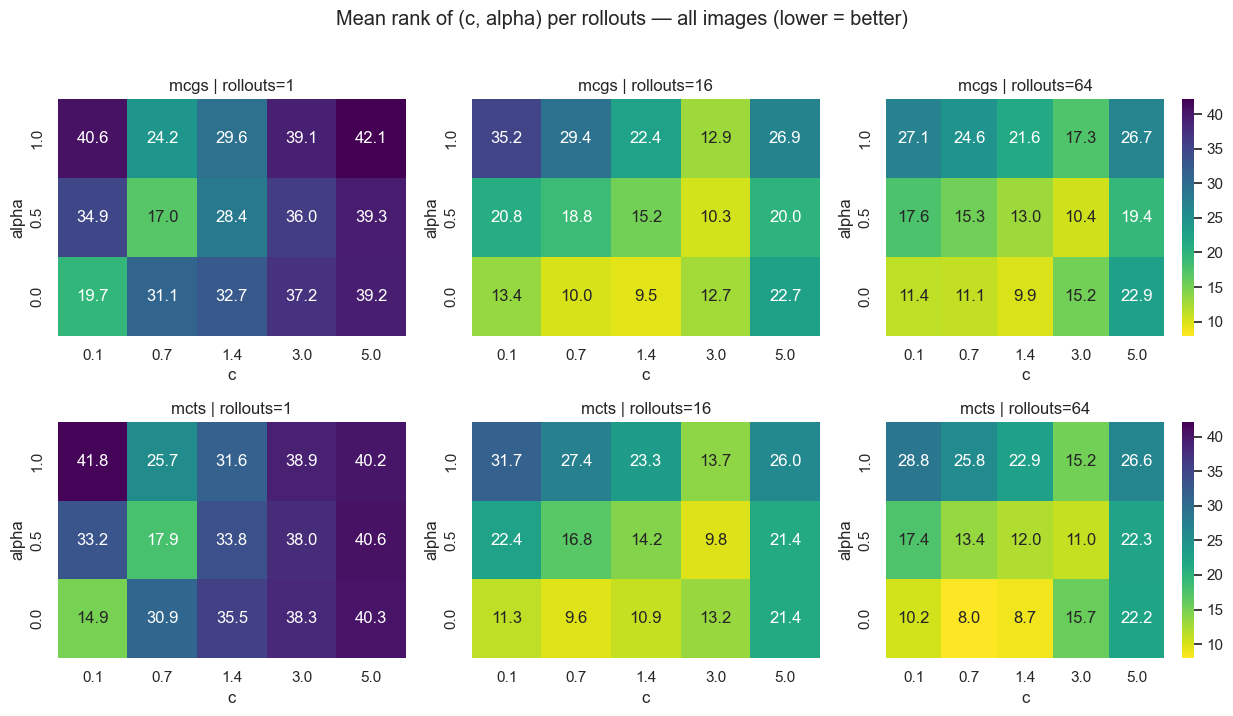


Top 10 configs by mean rank Ã¢â‚¬â€ mcgs (all images)
 num_rollouts   c  alpha  rank_mean  rank_std  n_images
           16 1.4    0.0   9.533333  8.920079        30
           64 1.4    0.0   9.866667  8.194756        30
           16 0.7    0.0  10.033333  7.997773        30
           16 3.0    0.5  10.300000  9.311283        30
           64 3.0    0.5  10.366667  7.849811        30
           64 0.7    0.0  11.066667  9.996321        30
           64 0.1    0.0  11.400000  9.167409        30
           16 3.0    0.0  12.733333  8.345692        30
           16 3.0    1.0  12.933333  8.521508        30
           64 1.4    0.5  12.966667  7.411470        30

Top 10 configs by mean rank Ã¢â‚¬â€ mcts (all images)
 num_rollouts   c  alpha  rank_mean  rank_std  n_images
           64 0.7    0.0   7.950000  7.225852        30
           64 1.4    0.0   8.666667  7.502107        30
           16 0.7    0.0   9.616667  8.745130        30
           16 3.0    0.5   9.800000  8.014642   

In [20]:
def rank_analysis(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """Rank configs per image (within each algorithm), aggregate mean rank per config."""
    df = df.dropna(subset=["rel_drop", "num_rollouts", "c", "alpha"]).copy()
    # rank within (algorithm, image_name); 1 = highest rel_drop.
    df["rank"] = df.groupby(["algorithm", "image_name"])["rel_drop"].rank(
        method="average", ascending=False
    )
    rank_agg = (
        df.groupby(["algorithm", "num_rollouts", "c", "alpha"])["rank"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .rename(columns={"mean": "rank_mean", "std": "rank_std", "count": "n_images"})
    )

    # Heatmaps: lower rank = greener.
    algos = sorted(rank_agg["algorithm"].dropna().unique())
    rollouts = sorted(rank_agg["num_rollouts"].dropna().unique())
    fig, axes = plt.subplots(
        len(algos),
        len(rollouts),
        figsize=(4.2 * len(rollouts), 3.5 * len(algos)),
        squeeze=False,
    )
    vmin, vmax = rank_agg["rank_mean"].min(), rank_agg["rank_mean"].max()
    for i, algo in enumerate(algos):
        for j, rl in enumerate(rollouts):
            ax = axes[i][j]
            sub = rank_agg[
                (rank_agg["algorithm"] == algo) & (rank_agg["num_rollouts"] == rl)
            ]
            if sub.empty:
                ax.set_axis_off()
                continue
            pivot = sub.pivot_table(
                index="alpha", columns="c", values="rank_mean", aggfunc="mean"
            )
            sns.heatmap(
                pivot,
                ax=ax,
                annot=True,
                fmt=".1f",
                cmap="viridis_r",
                vmin=vmin,
                vmax=vmax,
                cbar=(j == len(rollouts) - 1),
            )
            ax.set_title(f"{algo} | rollouts={int(rl)}")
            ax.invert_yaxis()
    fig.suptitle(
        f"Mean rank of (c, alpha) per rollouts Ã¢â‚¬â€ {label} (lower = better)", y=1.02
    )
    fig.tight_layout()
    plt.show()

    # Top-K table.
    TOP_K = 10
    for algo in algos:
        sub = rank_agg[rank_agg["algorithm"] == algo].sort_values("rank_mean")
        print(f"\nTop {TOP_K} configs by mean rank Ã¢â‚¬â€ {algo} ({label})")
        print(
            sub[["num_rollouts", "c", "alpha", "rank_mean", "rank_std", "n_images"]]
            .head(TOP_K)
            .to_string(index=False)
        )
    return rank_agg


rank_full = rank_analysis(child_runs, "all images")

### Same ranking, but on the filtered (non-stubborn) subset

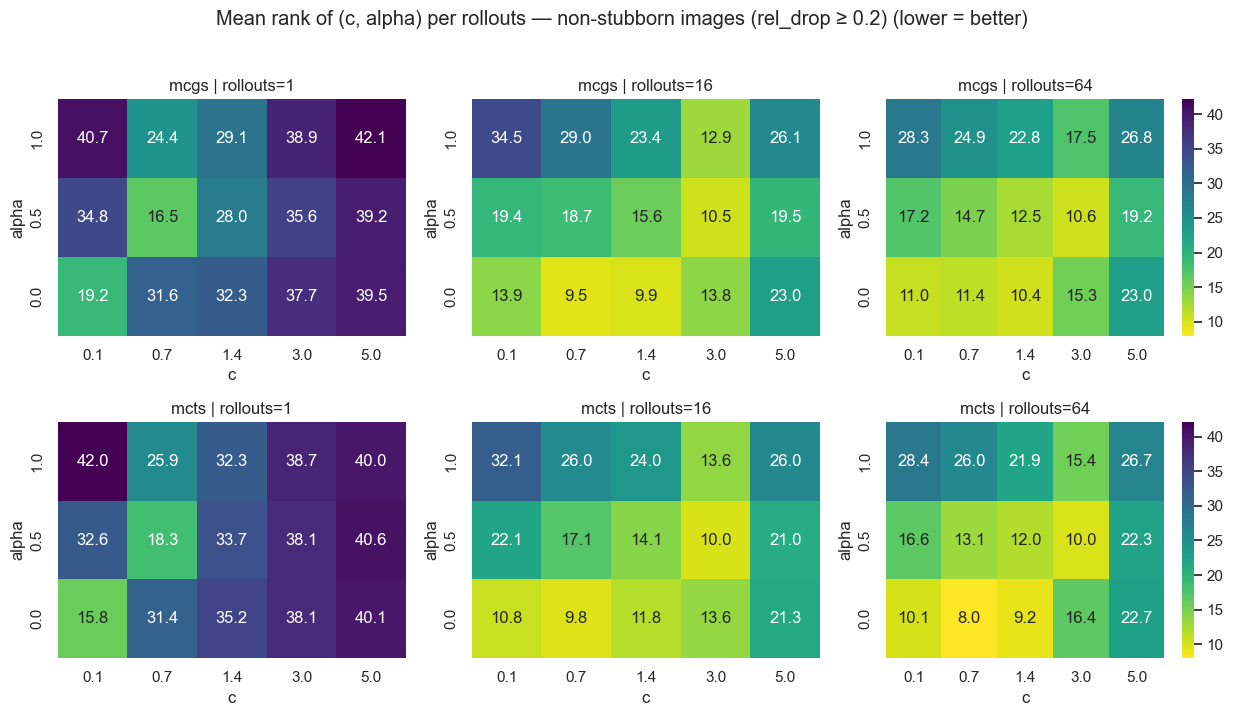


Top 10 configs by mean rank Ã¢â‚¬â€ mcgs (non-stubborn images (rel_drop Ã¢â€°Â¥ 0.2))
 num_rollouts   c  alpha  rank_mean  rank_std  n_images
           16 0.7    0.0   9.481481  7.521100        27
           16 1.4    0.0   9.925926  9.306433        27
           64 1.4    0.0  10.407407  8.463766        27
           16 3.0    0.5  10.518519  9.390545        27
           64 3.0    0.5  10.592593  8.177169        27
           64 0.1    0.0  10.962963  9.316988        27
           64 0.7    0.0  11.370370 10.437168        27
           64 1.4    0.5  12.481481  7.376524        27
           16 3.0    1.0  12.925926  8.548171        27
           16 3.0    0.0  13.777778  8.135078        27

Top 10 configs by mean rank Ã¢â‚¬â€ mcts (non-stubborn images (rel_drop Ã¢â€°Â¥ 0.2))
 num_rollouts   c  alpha  rank_mean  rank_std  n_images
           64 0.7    0.0   7.981481  7.293940        27
           64 1.4    0.0   9.185185  7.710069        27
           16 0.7    0.0   9.833333  9.0

In [21]:
rank_filt = rank_analysis(
    child_runs_filt, f"non-stubborn images (rel_drop Ã¢â€°Â¥ {STUBBORN_THRESHOLD})"
)

## Per-image normalized scores and win counts

For each image, `rel_drop` is normalized to [0, 1] across all configs (algorithm x rollouts x c x alpha). We then count winners per image, with an optional decisive-margin threshold.

In [22]:
WIN_MARGIN = 0.05  # minimum normalized-score gap for a decisive win


def _add_norm_scores(df: pd.DataFrame) -> pd.DataFrame:
    def _norm(grp: pd.DataFrame) -> pd.DataFrame:
        mn, mx = grp["rel_drop"].min(), grp["rel_drop"].max()
        grp = grp.copy()
        grp["norm_score"] = 0.5 if mx == mn else (grp["rel_drop"] - mn) / (mx - mn)
        return grp

    return df.groupby("image_name", group_keys=False).apply(_norm)


def _count_wins(df: pd.DataFrame, margin: float) -> pd.DataFrame:
    group_cols = ["algorithm", "num_rollouts", "c", "alpha"]
    records = []
    for _, grp in df.groupby("image_name"):
        valid = grp.dropna(subset=["norm_score"])
        if len(valid) < 2:
            continue
        ranked = valid.nlargest(len(valid), "norm_score")
        if (
            margin == 0.0
            or (ranked.iloc[0]["norm_score"] - ranked.iloc[1]["norm_score"]) > margin
        ):
            records.append(ranked.iloc[0][group_cols].to_dict())
    if not records:
        return pd.DataFrame(columns=group_cols + ["wins"])
    rec = pd.DataFrame(records)
    return rec.groupby(group_cols).size().reset_index(name="wins")


child_runs_n = _add_norm_scores(child_runs)

_wins_no = _count_wins(child_runs_n, 0.0)
_wins_mg = _count_wins(child_runs_n, WIN_MARGIN)

GROUP_NORM = ["algorithm", "num_rollouts", "c", "alpha"]

norm_sum = (
    child_runs_n.groupby(GROUP_NORM)["norm_score"]
    .agg(norm_score_mean="mean", norm_score_std="std")
    .reset_index()
    .merge(
        _wins_no.rename(columns={"wins": "wins_no_margin"}), on=GROUP_NORM, how="left"
    )
    .merge(
        _wins_mg.rename(columns={"wins": "wins_decisive"}),
        on=GROUP_NORM,
        how="left",
    )
    .fillna({"wins_no_margin": 0, "wins_decisive": 0})
    .sort_values("norm_score_mean", ascending=False)
    .reset_index(drop=True)
)

norm_sum[["wins_no_margin", "wins_decisive"]] = norm_sum[
    ["wins_no_margin", "wins_decisive"]
].astype(int)

_n_img = child_runs_n["image_name"].nunique()
_n_dec = int(_wins_mg["wins"].sum()) if not _wins_mg.empty else 0
print(
    f"Total images: {_n_img}  |  Decisive winners (margin={WIN_MARGIN}): {_n_dec}/{_n_img}"
)
print("\nTop 15 configs by mean normalized per-image score:")
display(norm_sum.head(15).round(4))

Total images: 30  |  Decisive winners (margin=0.05): 9/30

Top 15 configs by mean normalized per-image score:


TEMP_DIR/ipykernel_27300\2274917233.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("image_name", group_keys=False).apply(_norm)


,algorithm,num_rollouts,c,alpha,norm_score_mean,norm_score_std,wins_no_margin,wins_decisive
0,mcgs,16,1.4,0.0,0.8277,0.1830,0,0
1,mcgs,64,1.4,0.0,0.8263,0.1604,2,0
2,mcts,64,1.4,0.0,0.8250,0.1902,3,0
3,mcts,16,0.7,0.0,0.8246,0.2059,3,1
4,mcts,64,0.7,0.0,0.8154,0.2095,1,0
5,mcgs,16,3.0,0.5,0.8149,0.2146,3,2
6,mcgs,64,3.0,0.5,0.8060,0.1586,1,0
7,mcgs,16,0.7,0.0,0.8056,0.2407,0,0
8,mcts,64,0.1,0.0,0.8020,0.2363,1,0
9,mcts,16,1.4,0.0,0.7952,0.1939,1,0


## Per-image winners

For each image, find the single best config (highest `rel_drop`) per algorithm. Then count how often each config wins across images.

In [23]:
def best_per_image_table(df: pd.DataFrame) -> pd.DataFrame:
    """For each (algorithm, image_name), pick the row with highest rel_drop."""
    df = df.dropna(subset=["rel_drop", "num_rollouts", "c", "alpha"])
    idx = df.groupby(["algorithm", "image_name"])["rel_drop"].idxmax()
    best = (
        df.loc[
            idx,
            [
                "algorithm",
                "image_name",
                "num_rollouts",
                "c",
                "alpha",
                "original_prob",
                "prob_drop",
                "rel_drop",
            ],
        ]
        .sort_values(["algorithm", "image_name"])
        .reset_index(drop=True)
    )
    return best


best_per_img = best_per_image_table(child_runs)
for algo in sorted(best_per_img["algorithm"].dropna().unique()):
    sub = best_per_img[best_per_img["algorithm"] == algo]
    print(f"\nBest config per image Ã¢â‚¬â€ {algo}")
    print(sub.drop(columns=["algorithm"]).to_string(index=False))


Best config per image Ã¢â‚¬â€ mcgs
        image_name  num_rollouts   c  alpha  original_prob  prob_drop  rel_drop
imagenets_0000.jpg            16 5.0    0.5       0.996328   0.884156  0.887415
imagenets_0001.jpg            16 1.4    0.0       0.992200   0.867592  0.874413
imagenets_0002.jpg            64 3.0    0.5       0.942639   0.555026  0.588800
imagenets_0003.jpg            64 0.7    0.0       0.622759   0.613483  0.985105
imagenets_0004.jpg            16 3.0    0.5       0.999721   0.352101  0.352200
imagenets_0005.jpg            64 0.1    0.0       0.936011   0.935618  0.999579
imagenets_0006.jpg            64 0.7    0.0       0.986929   0.649169  0.657767
imagenets_0007.jpg            64 0.7    1.0       0.431292   0.405643  0.940529
imagenets_0008.jpg            16 0.1    0.5       0.393258   0.393144  0.999709
imagenets_0009.jpg            64 0.1    0.5       0.945437   0.800530  0.846731
imagenets_0010.jpg            64 1.4    0.0       0.941098   0.941044  0.999943
ima

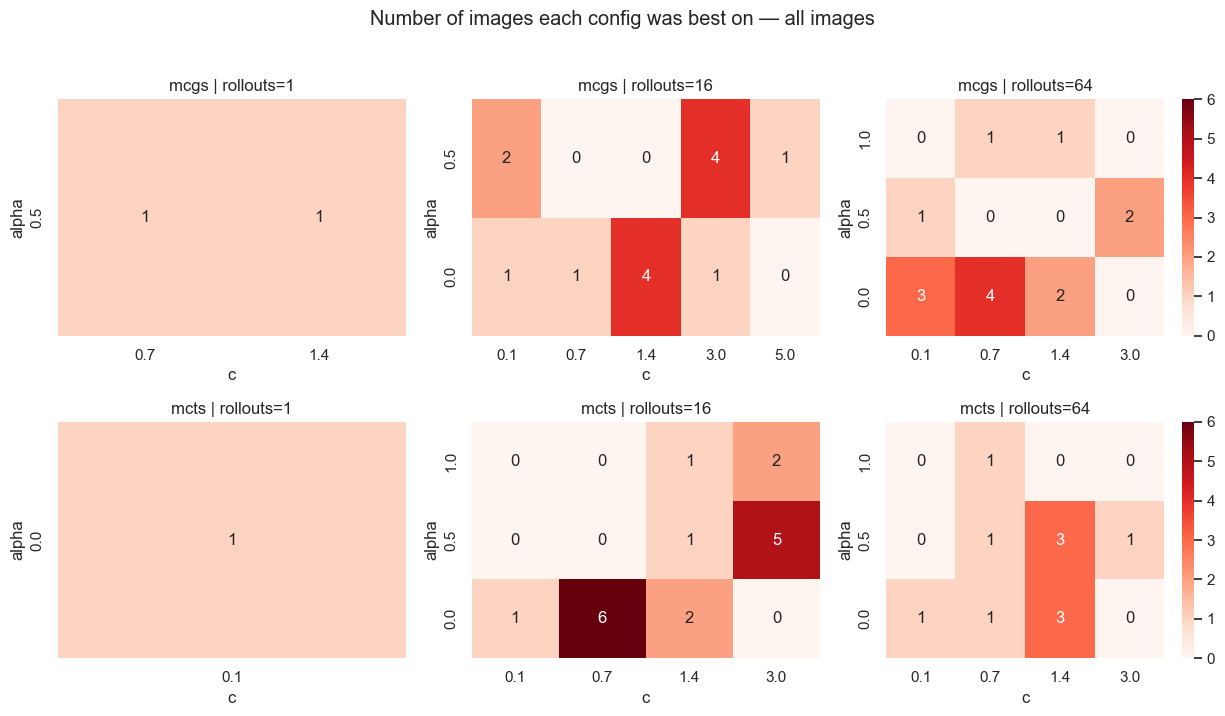

In [24]:
def wins_heatmap(best: pd.DataFrame, label: str) -> None:
    """Heatmap of how many images each config was best on, faceted by algorithm Ãƒâ€” rollouts."""
    counts = (
        best.groupby(["algorithm", "num_rollouts", "c", "alpha"])
        .size()
        .rename("wins")
        .reset_index()
    )
    algos = sorted(counts["algorithm"].dropna().unique())
    rollouts = sorted(counts["num_rollouts"].dropna().unique())
    fig, axes = plt.subplots(
        len(algos),
        len(rollouts),
        figsize=(4.2 * len(rollouts), 3.5 * len(algos)),
        squeeze=False,
    )
    vmax = counts["wins"].max()
    for i, algo in enumerate(algos):
        for j, rl in enumerate(rollouts):
            ax = axes[i][j]
            sub = counts[(counts["algorithm"] == algo) & (counts["num_rollouts"] == rl)]
            pivot = sub.pivot_table(
                index="alpha",
                columns="c",
                values="wins",
                aggfunc="sum",
                fill_value=0,
            )
            sns.heatmap(
                pivot,
                ax=ax,
                annot=True,
                fmt="d",
                cmap="Reds",
                vmin=0,
                vmax=vmax,
                cbar=(j == len(rollouts) - 1),
            )
            ax.set_title(f"{algo} | rollouts={int(rl)}")
            ax.invert_yaxis()
    fig.suptitle(f"Number of images each config was best on Ã¢â‚¬â€ {label}", y=1.02)
    fig.tight_layout()
    plt.show()


wins_heatmap(best_per_img, "all images")

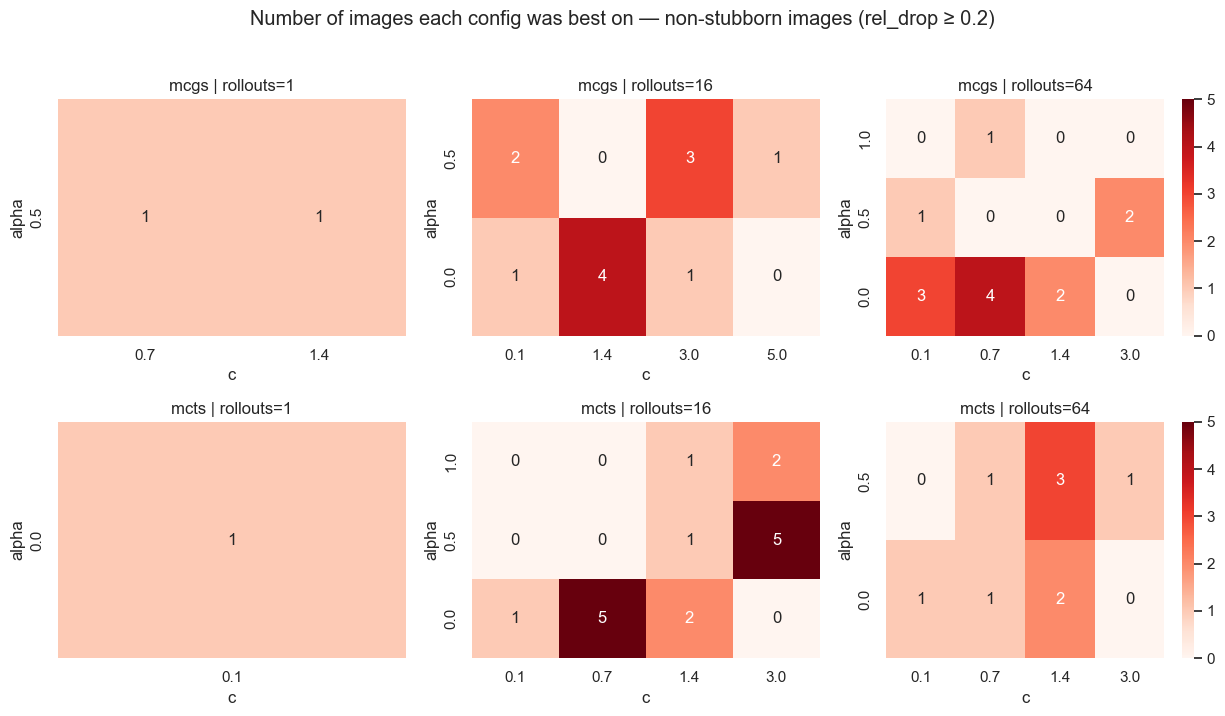

In [25]:
best_per_img_filt = best_per_image_table(child_runs_filt)
wins_heatmap(
    best_per_img_filt, f"non-stubborn images (rel_drop Ã¢â€°Â¥ {STUBBORN_THRESHOLD})"
)

## Per-image best, MCGS vs MCTS side-by-side

For each image: best (rollouts, c, alpha) within MCGS and within MCTS, and which algorithm wins head-to-head on that image.

In [26]:
def best_side_by_side(best: pd.DataFrame) -> pd.DataFrame:
    """Reshape per-(algorithm,image) best rows into one row per image with algo-suffixed columns."""
    cols = ["num_rollouts", "c", "alpha", "prob_drop", "rel_drop"]
    pieces = []
    for algo in sorted(best["algorithm"].dropna().unique()):
        sub = (
            best[best["algorithm"] == algo]
            .set_index("image_name")[cols + ["original_prob"]]
            .rename(columns={c: f"{c}_{algo}" for c in cols + ["original_prob"]})
        )
        pieces.append(sub)
    wide = pd.concat(pieces, axis=1)
    # original_prob is duplicated across algos (same image, same model) -> coalesce.
    op_cols = [c for c in wide.columns if c.startswith("original_prob_")]
    wide["original_prob"] = wide[op_cols].bfill(axis=1).iloc[:, 0]
    wide = wide.drop(columns=op_cols)
    if "rel_drop_mcgs" in wide.columns and "rel_drop_mcts" in wide.columns:
        wide["winner"] = np.where(
            wide["rel_drop_mcgs"] > wide["rel_drop_mcts"],
            "mcgs",
            np.where(wide["rel_drop_mcts"] > wide["rel_drop_mcgs"], "mcts", "tie"),
        )
        wide["rel_drop_diff"] = wide["rel_drop_mcgs"] - wide["rel_drop_mcts"]
    return wide.sort_values("original_prob").reset_index()


sbs = best_side_by_side(best_per_img)
print("Per-image best config Ã¢â‚¬â€ MCGS vs MCTS")
print(sbs.to_string(index=False))

if "winner" in sbs.columns:
    print("\nHead-to-head winner counts:")
    print(sbs["winner"].value_counts().to_string())

Per-image best config Ã¢â‚¬â€ MCGS vs MCTS
        image_name  num_rollouts_mcgs  c_mcgs  alpha_mcgs  prob_drop_mcgs  rel_drop_mcgs  num_rollouts_mcts  c_mcts  alpha_mcts  prob_drop_mcts  rel_drop_mcts  original_prob winner  rel_drop_diff
imagenets_0008.jpg                 16     0.1         0.5        0.393144       0.999709                 64     3.0         0.5        0.392825       0.998898       0.393258   mcgs       0.000810
imagenets_0007.jpg                 64     0.7         1.0        0.405643       0.940529                 16     3.0         1.0        0.396295       0.918856       0.431292   mcgs       0.021674
imagenets_0028.jpg                 64     1.4         0.0        0.443176       0.999853                 16     1.4         0.0        0.443174       0.999851       0.443241   mcgs       0.000002
imagenets_0012.jpg                 16     0.1         0.5        0.497911       0.999283                 64     0.7         0.0        0.497927       0.999316       0.49826

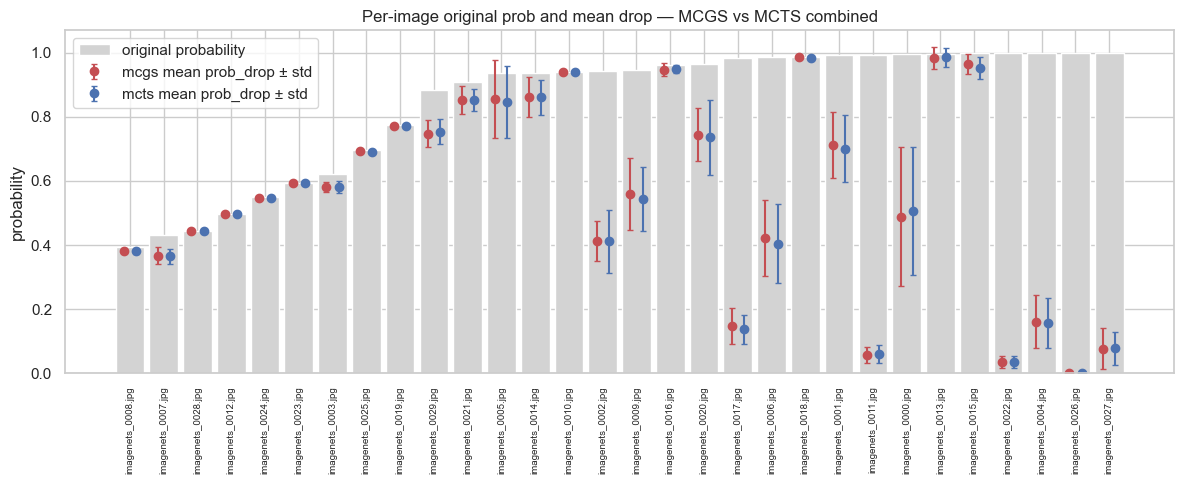

In [27]:
algos = sorted(per_image["algorithm"].dropna().unique())
fig, ax = plt.subplots(figsize=(max(10, 0.4 * len(order)), 5))
x = np.arange(len(order))

# Use original_prob from any algorithm (identical: same image, same model).
ref = (
    per_image[per_image["algorithm"] == algos[0]].set_index("image_name").reindex(order)
)
ax.bar(
    x, ref["original_prob"], color="lightgray", label="original probability", width=0.85
)

offsets = np.linspace(-0.18, 0.18, len(algos))
colors = ["C3", "C0", "C2", "C1"]
for algo, off, color in zip(algos, offsets, colors, strict=False):
    sub = (
        per_image[per_image["algorithm"] == algo].set_index("image_name").reindex(order)
    )
    ax.errorbar(
        x + off,
        sub["prob_drop_mean"],
        yerr=sub["prob_drop_std"],
        fmt="o",
        color=color,
        ecolor=color,
        capsize=2,
        label=f"{algo} mean prob_drop Ã‚Â± std",
    )
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=90, fontsize=7)
ax.set_ylabel("probability")
ax.set_title("Per-image original prob and mean drop Ã¢â‚¬â€ MCGS vs MCTS combined")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

## Wins heatmap Ã¢â‚¬â€ single winner per image (across both algorithms)

For each image, pick the single best config across MCGS *and* MCTS together (so totals sum to 30, not 60).

Total winners (one per image): 30

Winning algorithm counts:
algorithm
mcts    16
mcgs    14


REPO_ROOT/.venv\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
REPO_ROOT/.venv\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


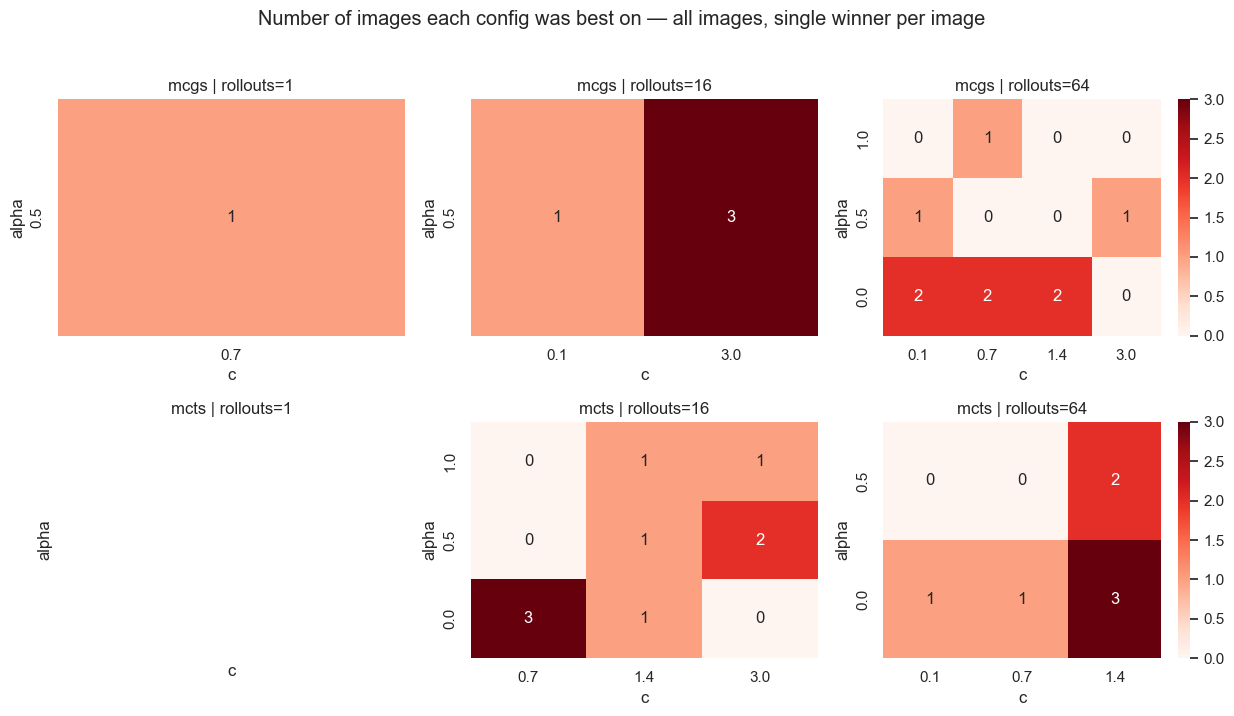

In [28]:
def best_per_image_combined(df: pd.DataFrame) -> pd.DataFrame:
    """For each image, pick the single best (algorithm, rollouts, c, alpha) by rel_drop."""
    df = df.dropna(subset=["rel_drop", "num_rollouts", "c", "alpha"])
    idx = df.groupby("image_name")["rel_drop"].idxmax()
    return (
        df.loc[
            idx,
            [
                "image_name",
                "algorithm",
                "num_rollouts",
                "c",
                "alpha",
                "original_prob",
                "prob_drop",
                "rel_drop",
            ],
        ]
        .sort_values("image_name")
        .reset_index(drop=True)
    )


best_combined = best_per_image_combined(child_runs)
print(f"Total winners (one per image): {len(best_combined)}")
print("\nWinning algorithm counts:")
print(best_combined["algorithm"].value_counts().to_string())

wins_heatmap(best_combined, "all images, single winner per image")

REPO_ROOT/.venv\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
REPO_ROOT/.venv\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


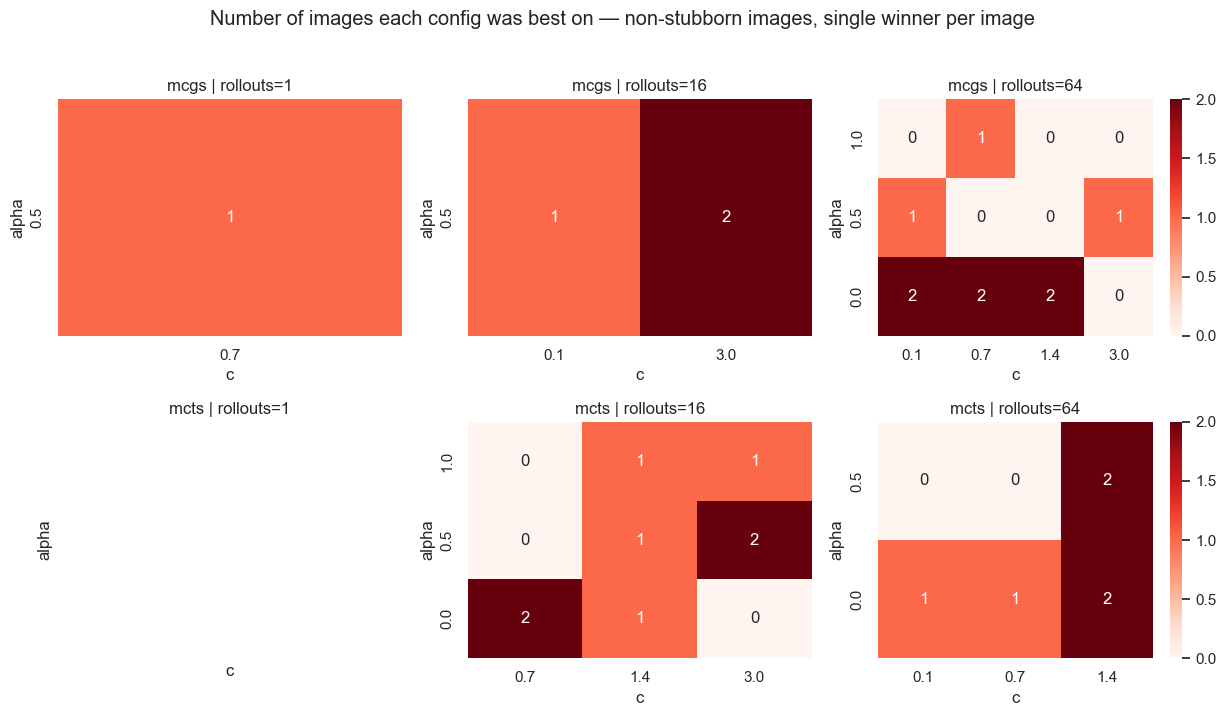

In [29]:
best_combined_filt = best_per_image_combined(child_runs_filt)
wins_heatmap(best_combined_filt, "non-stubborn images, single winner per image")

---
## Convergence / time analysis

Each child run logs two trajectory metrics keyed by `step = num_evals`:
- `region_0/trajectory_best_score` Ã¢â‚¬â€ best score found so far
- `region_0/trajectory_time` Ã¢â‚¬â€ elapsed wall time in seconds at that step

Loading trajectory requires one API call per run Ã¢â‚¬â€ can be slow for all 2700 runs. `MAX_TRAJ_RUNS` limits it.

In [30]:
from tqdm.auto import tqdm


MAX_TRAJ_RUNS = (
    300  # Set to an int (e.g. 300) to load a random subset; None = load all.
)

SCORE_METRIC = "region_0/trajectory_best_score"
TIME_METRIC = "region_0/trajectory_time"
INTERP_POINTS = 200  # Resolution of the common grid for mean/band plots.


def load_trajectories(runs_df: pd.DataFrame) -> pd.DataFrame:
    """Fetch trajectory history for each run_id in runs_df.
    Returns long-format DataFrame with columns:
      run_id, algorithm, image_name, num_rollouts, c, alpha,
      evals (step), best_score, elapsed_time.
    """
    sample = runs_df.copy()
    if MAX_TRAJ_RUNS is not None and len(sample) > MAX_TRAJ_RUNS:
        sample = sample.sample(MAX_TRAJ_RUNS, random_state=42)
    records = []
    for _, row in tqdm(
        sample.iterrows(), total=len(sample), desc="loading trajectories"
    ):
        run_id = row["run_id"]
        try:
            score_hist = client.get_metric_history(run_id, SCORE_METRIC)
            time_hist = client.get_metric_history(run_id, TIME_METRIC)
        except Exception:
            continue
        time_by_step = {m.step: m.value for m in time_hist}
        for m in score_hist:
            records.append(
                {
                    "run_id": run_id,
                    "algorithm": row["algorithm"],
                    "image_name": row["image_name"],
                    "num_rollouts": row["num_rollouts"],
                    "c": row["c"],
                    "alpha": row["alpha"],
                    "evals": m.step,
                    "best_score": m.value,
                    "elapsed_time": time_by_step.get(m.step, np.nan),
                }
            )
    return pd.DataFrame(records)


traj = load_trajectories(child_runs.reset_index())
print(f"Loaded {traj['run_id'].nunique()} runs, {len(traj)} trajectory points")
traj.head()

loading trajectories:   0%|          | 0/300 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Convergence curves Ã¢â‚¬â€ 3 random images

One subplot per image. Each curve = one (algorithm, rollouts, c, alpha) config, coloured by algorithm. Time on x-axis (wall seconds) so the comparison is time-fair.

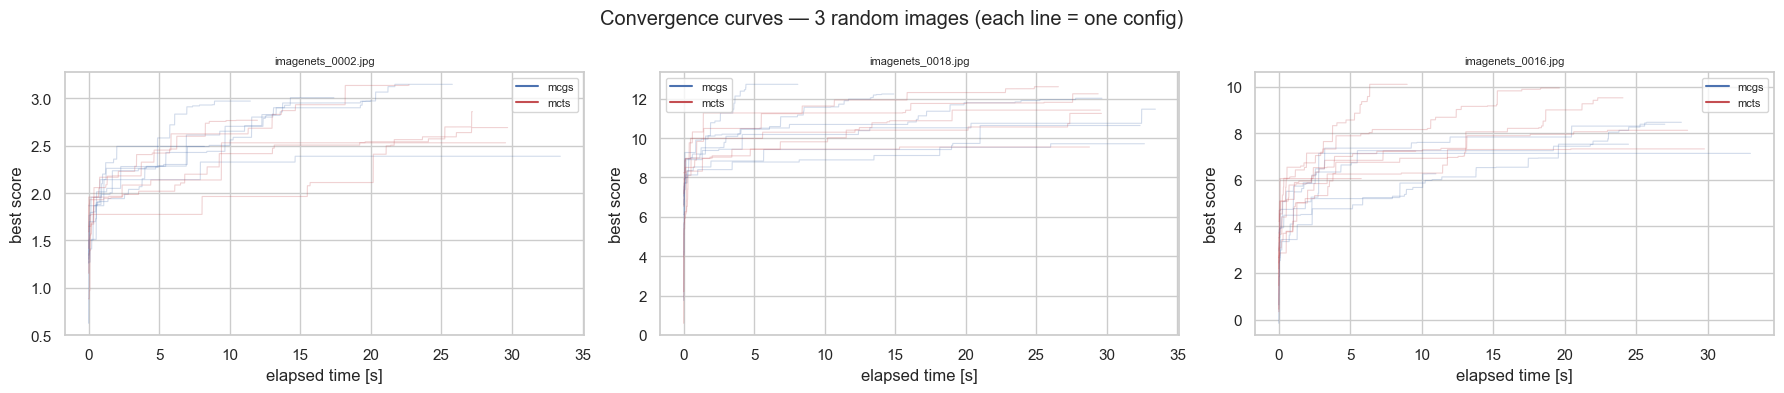

In [26]:
SAMPLE_IMAGES = traj["image_name"].dropna().unique()
rng = np.random.default_rng(0)
sample_imgs = rng.choice(SAMPLE_IMAGES, size=min(3, len(SAMPLE_IMAGES)), replace=False)

algo_color = {"mcgs": "C0", "mcts": "C3"}

fig, axes = plt.subplots(
    1, len(sample_imgs), figsize=(6 * len(sample_imgs), 4), squeeze=False
)
for ax, img in zip(axes[0], sample_imgs, strict=False):
    sub = traj[traj["image_name"] == img].dropna(subset=["elapsed_time"])
    for (algo, rl, c, alpha), grp in sub.groupby(
        ["algorithm", "num_rollouts", "c", "alpha"]
    ):
        grp = grp.sort_values("elapsed_time")
        ax.plot(
            grp["elapsed_time"],
            grp["best_score"],
            color=algo_color.get(algo, "gray"),
            alpha=0.25,
            linewidth=0.8,
        )
    # Legend proxies.
    for algo, color in algo_color.items():
        ax.plot([], [], color=color, label=algo)
    ax.set_title(img, fontsize=8)
    ax.set_xlabel("elapsed time [s]")
    ax.set_ylabel("best score")
    ax.legend(fontsize=8)
fig.suptitle("Convergence curves Ã¢â‚¬â€ 3 random images (each line = one config)")
fig.tight_layout()
plt.show()

### Mean convergence across all images Ã¢â‚¬â€ with confidence band

Trajectories are interpolated onto a common time grid per run, then averaged across images per algorithm. Band = Ã‚Â±1 std.

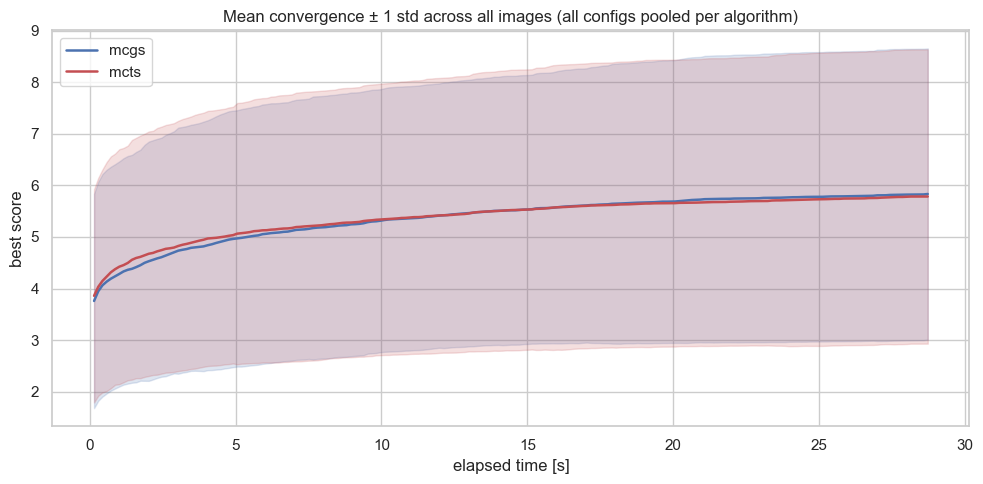

In [27]:
def interpolate_to_grid(grp: pd.DataFrame, grid: np.ndarray, x_col: str) -> np.ndarray:
    """Step-interpolate a monotone trajectory onto a fixed grid."""
    grp = grp.dropna(subset=[x_col, "best_score"]).sort_values(x_col)
    if len(grp) < 2:
        return np.full(len(grid), np.nan)
    return np.interp(
        grid,
        grp[x_col].values,
        grp["best_score"].values,
        left=np.nan,
        right=grp["best_score"].iloc[-1],
    )


t_max = traj["elapsed_time"].quantile(0.95)  # clip outliers
time_grid = np.linspace(0, t_max, INTERP_POINTS)

records = []
for (algo, img, rl, c, alpha), grp in traj.groupby(
    ["algorithm", "image_name", "num_rollouts", "c", "alpha"]
):
    interp = interpolate_to_grid(grp, time_grid, "elapsed_time")
    for t, v in zip(time_grid, interp, strict=False):
        records.append(
            {
                "algorithm": algo,
                "image_name": img,
                "num_rollouts": rl,
                "c": c,
                "alpha": alpha,
                "time": t,
                "best_score": v,
            }
        )

traj_interp = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(10, 5))
for algo, color in algo_color.items():
    sub = traj_interp[traj_interp["algorithm"] == algo].dropna(subset=["best_score"])
    mean = sub.groupby("time")["best_score"].mean()
    std = sub.groupby("time")["best_score"].std()
    ax.plot(mean.index, mean.values, color=color, label=algo, linewidth=1.8)
    ax.fill_between(mean.index, mean - std, mean + std, color=color, alpha=0.18)
ax.set_xlabel("elapsed time [s]")
ax.set_ylabel("best score")
ax.set_title(
    "Mean convergence Ã‚Â± 1 std across all images (all configs pooled per algorithm)"
)
ax.legend()
fig.tight_layout()
plt.show()

### Fixed-time snapshot comparison

Find the earliest time at which any config finishes (p5 of final times = the "fastest" configs). Snapshot every config's score at that time, then compare.

Fixed snapshot time T = 5.76s  (p5 of per-run final times)


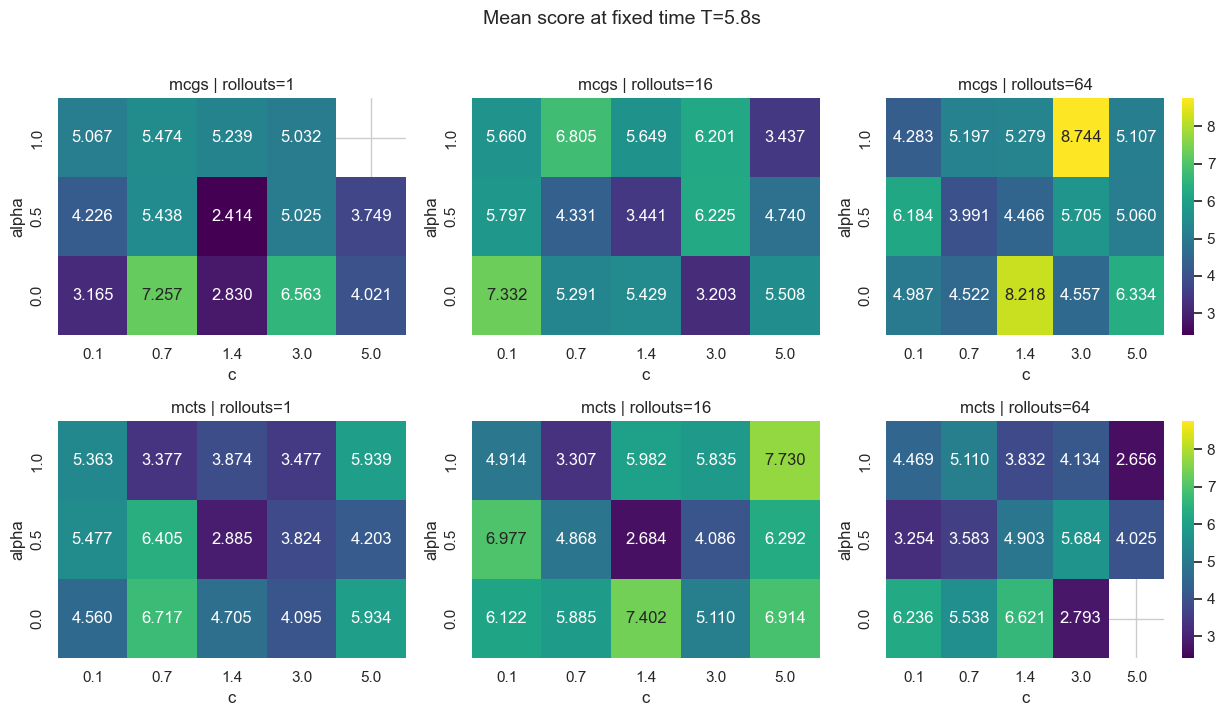

In [28]:
# Final time per run = max elapsed_time in its trajectory.
final_times = (
    traj.dropna(subset=["elapsed_time"]).groupby("run_id")["elapsed_time"].max()
)
T_fixed = float(
    final_times.quantile(0.05)
)  # Time when the fastest 5% of configs finish.
print(f"Fixed snapshot time T = {T_fixed:.2f}s  (p5 of per-run final times)")

# For each run, interpolate score at T_fixed.
snapshot_records = []
for (algo, img, rl, c, alpha), grp in traj.groupby(
    ["algorithm", "image_name", "num_rollouts", "c", "alpha"]
):
    score_at_T = interpolate_to_grid(grp, np.array([T_fixed]), "elapsed_time")[0]
    snapshot_records.append(
        {
            "algorithm": algo,
            "image_name": img,
            "num_rollouts": rl,
            "c": c,
            "alpha": alpha,
            "score_at_T": score_at_T,
        }
    )

snapshot = pd.DataFrame(snapshot_records).dropna(subset=["score_at_T"])

# Aggregate: mean score at T per config.
snap_agg = (
    snapshot.groupby(["algorithm", "num_rollouts", "c", "alpha"])["score_at_T"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"mean": "score_at_T_mean", "std": "score_at_T_std"})
)

plot_heatmap_grid(
    snap_agg.rename(columns={"score_at_T_mean": "snap_mean"}),
    "snap_mean",
    f"Mean score at fixed time T={T_fixed:.1f}s",
)

### Mean convergence per config across all images

One curve per (algorithm, rollouts, c, alpha). Coloured by algorithm, faceted by `num_rollouts`. Gives a sense of which configs converge fastest on average.

In [31]:
rollout_values = sorted(traj_interp["num_rollouts"].dropna().unique())
fig, axes = plt.subplots(
    1, len(rollout_values), figsize=(6 * len(rollout_values), 4), squeeze=False
)

for ax, rl in zip(axes[0], rollout_values, strict=False):
    sub = traj_interp[traj_interp["num_rollouts"] == rl]
    for (algo, c, alpha), grp in sub.groupby(["algorithm", "c", "alpha"]):
        mean = grp.groupby("time")["best_score"].mean()
        ax.plot(
            mean.index,
            mean.values,
            color=algo_color.get(algo, "gray"),
            alpha=0.4,
            linewidth=0.9,
        )
    for algo, color in algo_color.items():
        ax.plot([], [], color=color, label=algo, linewidth=1.5)
    ax.set_title(f"rollouts={int(rl)}")
    ax.set_xlabel("elapsed time [s]")
    ax.set_ylabel("mean best score")
    ax.legend(fontsize=8)

fig.suptitle(
    "Mean best score vs time Ã¢â‚¬â€ one curve per (c, alpha) config, faceted by num_rollouts"
)
fig.tight_layout()
plt.show()

NameError: name 'traj_interp' is not defined

### Mean wall time per config

Each cell shows the mean elapsed time (seconds) across all 30 images for that (c, alpha) combination, faceted by algorithm Ãƒâ€” num_rollouts. Lower = faster.

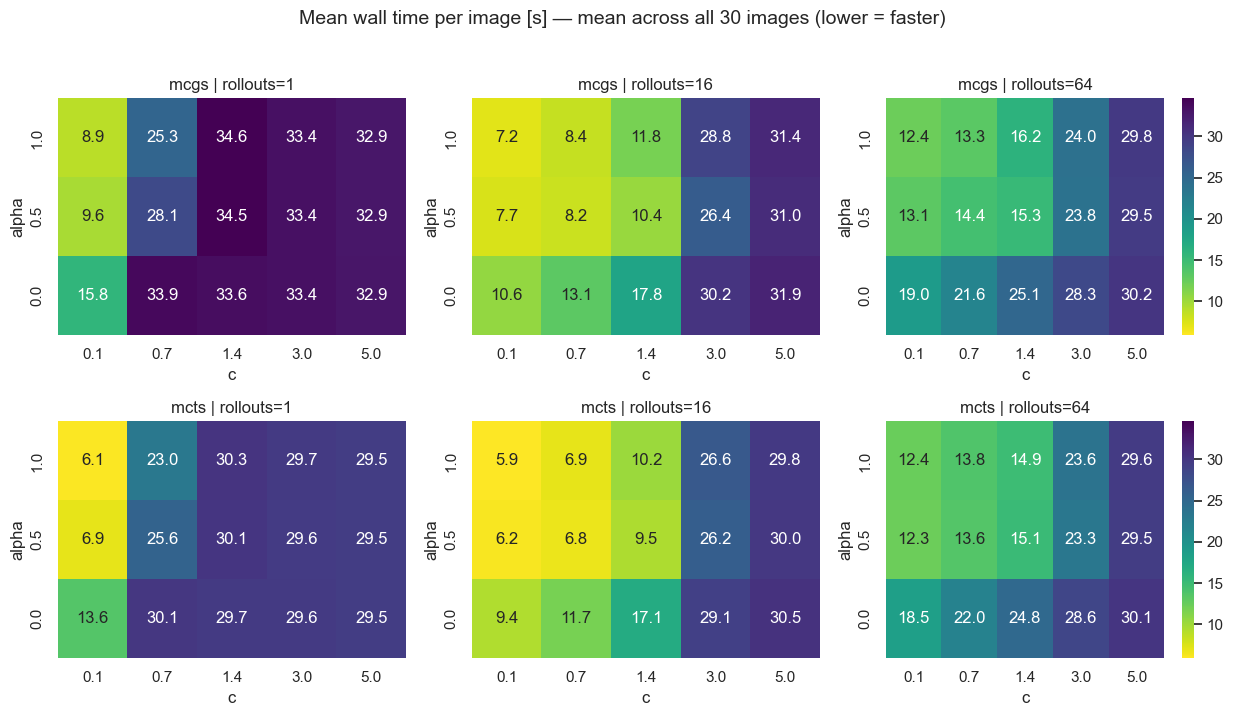

In [30]:
algos = sorted(agg["algorithm"].dropna().unique())
rollouts = sorted(agg["num_rollouts"].dropna().unique())

fig, axes = plt.subplots(
    len(algos),
    len(rollouts),
    figsize=(4.2 * len(rollouts), 3.5 * len(algos)),
    squeeze=False,
)
vmin = agg["time_s_mean"].min()
vmax = agg["time_s_mean"].max()

for i, algo in enumerate(algos):
    for j, rl in enumerate(rollouts):
        ax = axes[i][j]
        sub = agg[(agg["algorithm"] == algo) & (agg["num_rollouts"] == rl)]
        if sub.empty:
            ax.set_axis_off()
            continue
        pivot = sub.pivot_table(
            index="alpha", columns="c", values="time_s_mean", aggfunc="mean"
        )
        sns.heatmap(
            pivot,
            ax=ax,
            annot=True,
            fmt=".1f",
            cmap="viridis_r",
            vmin=vmin,
            vmax=vmax,
            cbar=(j == len(rollouts) - 1),
        )
        ax.set_title(f"{algo} | rollouts={int(rl)}")
        ax.invert_yaxis()

fig.suptitle(
    "Mean wall time per image [s] Ã¢â‚¬â€ mean across all 30 images (lower = faster)",
    fontsize=14,
    y=1.02,
)
fig.tight_layout()
plt.show()

In [31]:
agg.to_csv("grid_thesis_aggregated.csv", index=False)
print("Saved grid_thesis_aggregated.csv")

Saved grid_thesis_aggregated.csv
